# Stage 3 — ADR Detection
**Model:** XGBoost Classifier Chain | **20 ADR labels** | **WHO severity classification**

**Changes from original:**
- Fixed Cell 7 comment (said Cell 7, should say Cell 6)
- Removed duplicate Cell 13 encoders in Cell 15 (Cell 15 now only adds action_class)
- Deleted duplicate test Cell 23 (identical to Cell 22)
- Bootstrap ensemble now used in pipeline predict (not just saved and ignored)

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib, ast, os, warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.multioutput import ClassifierChain
from sklearn.model_selection import train_test_split
from sklearn.metrics import hamming_loss, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

print('All libraries imported')

All libraries imported


In [2]:
# Cell 2: Load Datasets
new_df         = pd.read_csv('../datasets/stage3/medicine_dataset.csv')
drugs_df       = pd.read_csv('../datasets/stage2/drugs_side_effects_drugs_com.csv')
medications_df = pd.read_csv('../datasets/stage1/medications.csv')
train_df       = pd.read_csv('../datasets/stage1/Training.csv')

print(f'medicine_dataset  : {new_df.shape}')
print(f'drugs_side_effects: {drugs_df.shape}')
print(f'medications       : {medications_df.shape}')
print(f'Training          : {train_df.shape}')

print(f'\nAll columns in medicine_dataset:')
for c in new_df.columns:
    print(f'  -> {c}')

medicine_dataset  : (248218, 58)
drugs_side_effects: (2931, 17)
medications       : (41, 2)
Training          : (4920, 133)

All columns in medicine_dataset:
  -> id
  -> name
  -> substitute0
  -> substitute1
  -> substitute2
  -> substitute3
  -> substitute4
  -> sideEffect0
  -> sideEffect1
  -> sideEffect2
  -> sideEffect3
  -> sideEffect4
  -> sideEffect5
  -> sideEffect6
  -> sideEffect7
  -> sideEffect8
  -> sideEffect9
  -> sideEffect10
  -> sideEffect11
  -> sideEffect12
  -> sideEffect13
  -> sideEffect14
  -> sideEffect15
  -> sideEffect16
  -> sideEffect17
  -> sideEffect18
  -> sideEffect19
  -> sideEffect20
  -> sideEffect21
  -> sideEffect22
  -> sideEffect23
  -> sideEffect24
  -> sideEffect25
  -> sideEffect26
  -> sideEffect27
  -> sideEffect28
  -> sideEffect29
  -> sideEffect30
  -> sideEffect31
  -> sideEffect32
  -> sideEffect33
  -> sideEffect34
  -> sideEffect35
  -> sideEffect36
  -> sideEffect37
  -> sideEffect38
  -> sideEffect39
  -> sideEffect40
  -> sideEf

In [3]:
# Cell 3: Explore Side Effect Columns
se_cols = [c for c in new_df.columns if c.startswith('sideEffect')]

print(f'Side effect columns: {len(se_cols)}')
print(f'Columns: {se_cols}')

print(f'\nSample side effects (row 1):')
for c in se_cols:
    val = new_df[c].iloc[1]
    if pd.notna(val):
        print(f'  {c}: {val}')

print(f'\nNon-null counts per column:')
for c in se_cols:
    count = new_df[c].notna().sum()
    pct   = count / len(new_df) * 100
    print(f'  {c:<15}: {count:>6} ({pct:.1f}%)')

Side effect columns: 42
Columns: ['sideEffect0', 'sideEffect1', 'sideEffect2', 'sideEffect3', 'sideEffect4', 'sideEffect5', 'sideEffect6', 'sideEffect7', 'sideEffect8', 'sideEffect9', 'sideEffect10', 'sideEffect11', 'sideEffect12', 'sideEffect13', 'sideEffect14', 'sideEffect15', 'sideEffect16', 'sideEffect17', 'sideEffect18', 'sideEffect19', 'sideEffect20', 'sideEffect21', 'sideEffect22', 'sideEffect23', 'sideEffect24', 'sideEffect25', 'sideEffect26', 'sideEffect27', 'sideEffect28', 'sideEffect29', 'sideEffect30', 'sideEffect31', 'sideEffect32', 'sideEffect33', 'sideEffect34', 'sideEffect35', 'sideEffect36', 'sideEffect37', 'sideEffect38', 'sideEffect39', 'sideEffect40', 'sideEffect41']

Sample side effects (row 1):
  sideEffect0: Vomiting
  sideEffect1: Nausea
  sideEffect2: Abdominal pain
  sideEffect3: Diarrhea

Non-null counts per column:
  sideEffect0    : 248218 (100.0%)
  sideEffect1    : 238416 (96.1%)
  sideEffect2    : 229500 (92.5%)
  sideEffect3    : 207638 (83.7%)
  sideEf

In [4]:
# Cell 4: Find Top 20 ADRs
se_cols = [c for c in new_df.columns if c.startswith('sideEffect')]

all_se = []
for c in se_cols:
    vals = new_df[c].dropna().str.strip().str.lower()
    all_se.extend(vals.tolist())

se_counts = Counter(all_se)
print(f'Total unique side effects : {len(se_counts)}')

TOP_N    = 20
TOP_ADRS = [se for se, _ in se_counts.most_common(TOP_N)]

print(f'\nTop {TOP_N} ADRs selected as labels:')
for i, a in enumerate(TOP_ADRS, 1):
    print(f'  {i:>2}. {a}')

Total unique side effects : 1053

Top 20 ADRs selected as labels:
   1. nausea
   2. diarrhea
   3. vomiting
   4. headache
   5. dizziness
   6. stomach pain
   7. rash
   8. dryness in mouth
   9. sleepiness
  10. flatulence
  11. abdominal pain
  12. indigestion
  13. constipation
  14. fatigue
  15. loss of appetite
  16. increased liver enzymes
  17. allergic reaction
  18. heartburn
  19. weakness
  20. insomnia (difficulty in sleeping)


In [5]:
# Cell 5: Load Sentence Transformer
print('Loading sentence transformer model...')
med_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Model loaded')

stage1_diseases_list = sorted(train_df['prognosis'].str.strip().unique())
stage1_vecs = med_model.encode(stage1_diseases_list)
print(f'Stage 1 diseases encoded: {len(stage1_diseases_list)}')

Loading sentence transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3303.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded
Stage 1 diseases encoded: 41


In [6]:
# Cell 6: Extract Disease from Medicine Dataset
use_cols = [c for c in new_df.columns if c.startswith('use')]
se_cols  = [c for c in new_df.columns if c.startswith('sideEffect')]

def extract_disease(text):
    if pd.isna(text):
        return None
    s = str(text).strip()
    for prefix in [
        'Treatment of ', 'treatment of ',
        'Prevention of ', 'prevention of ',
        'Management of ', 'management of ',
        'Used in ', 'used in ',
        'Used for ', 'used for ',
        'Treatment and prevention of ',
    ]:
        if s.startswith(prefix):
            s = s[len(prefix):]
    return s.strip()

new_df['disease_raw'] = new_df['use0'].apply(extract_disease)

print(f'Sample extracted diseases:')
for d in new_df['disease_raw'].dropna().head(10):
    print(f"  -> '{d}'")
print(f'\nUnique diseases: {new_df["disease_raw"].nunique()}')

Sample extracted diseases:
  -> 'Bacterial infections'
  -> 'Bacterial infections'
  -> 'Cough with mucus'
  -> 'Sneezing and runny nose due to allergies'
  -> 'Allergic conditions'
  -> 'Sneezing and runny nose due to allergies'
  -> 'Bacterial infections'
  -> 'Bacterial infections'
  -> 'Anxiety'
  -> 'Dry cough'

Unique diseases: 457


In [7]:
# Cell 7: Encode Stage 3 Diseases
# FIX: Comment was wrong — disease_raw created in Cell 6 (not Cell 7)
stage3_diseases = list(new_df['disease_raw'].dropna().unique())
stage3_vecs     = med_model.encode(stage3_diseases)
print(f'Stage 3 diseases encoded : {len(stage3_diseases)}')

Stage 3 diseases encoded : 457


In [8]:
# Cell 8: REMOVED — Duplicate Bidirectional Matching
# =====================================================
# This cell was doing the same bidirectional similarity
# matching as Cell 9 but storing result in 'clean_mapping'
# which was NEVER used in Cell 11.
#
# Cell 9 stores result in 'med_mapping' which IS used in Cell 11.
# This cell is kept as a placeholder — do NOT add code here.
# Run Cell 9 directly for the actual mapping.
# =====================================================
print("Cell 8 skipped — see Cell 9 for actual bidirectional mapping")


Cell 8 skipped — see Cell 9 for actual bidirectional mapping


In [9]:
# Cell 9: Final Medicine Dataset Mapping
med_diseases     = list(new_df['disease_raw'].dropna().unique())
med_disease_vecs = med_model.encode(med_diseases)

med_mapping = {}
rejected    = []

for i, disease in enumerate(med_diseases):
    fwd_sims   = cosine_similarity([med_disease_vecs[i]], stage1_vecs)[0]
    best_idx   = np.argmax(fwd_sims)
    best_match = stage1_diseases_list[best_idx]
    fwd_score  = float(fwd_sims[best_idx])

    bwd_sims     = cosine_similarity([stage1_vecs[best_idx]], med_disease_vecs)[0]
    bwd_best_idx = np.argmax(bwd_sims)
    bwd_best     = med_diseases[bwd_best_idx]
    bwd_score    = float(bwd_sims[bwd_best_idx])

    is_valid = (
        fwd_score >= 0.90 and bwd_best == disease and bwd_score >= 0.90
    )
    if is_valid:
        med_mapping[disease] = best_match

print(f'Auto-mapped diseases : {len(med_mapping)}')
print(f'Rejected             : {len(med_diseases) - len(med_mapping)}')
print('\nMapped diseases:')
for src, tgt in sorted(med_mapping.items()):
    print(f"  '{src}' -> '{tgt}'")

Auto-mapped diseases : 16
Rejected             : 441

Mapped diseases:
  'Acne' -> 'Acne'
  'Bacterial infections of urinary tract' -> 'Urinary tract infection'
  'Common cold' -> 'Common Cold'
  'Diabetes' -> 'Diabetes'
  'Fungal infections' -> 'Fungal infection'
  'Heart attack' -> 'Heart attack'
  'Hepatitis B infection' -> 'Hepatitis B'
  'Hyperthyroidism' -> 'Hyperthyroidism'
  'Hypothyroidism' -> 'Hypothyroidism'
  'Impetigo' -> 'Impetigo'
  'Malaria' -> 'Malaria'
  'Migraine' -> 'Migraine'
  'Psoriasis' -> 'Psoriasis'
  'Severe hypoglycemia' -> 'Hypoglycemia'
  'Tuberculosis (TB)' -> 'Tuberculosis'
  'Varicose veins' -> 'Varicose veins'


In [10]:
# Cell 10: Check Action/Class Columns
ac_cols = [c for c in new_df.columns
           if 'action' in c.lower() or 'class' in c.lower()]
print('Action/Class columns in medicine_dataset:')
for c in ac_cols:
    sample = new_df[c].dropna().iloc[0]
    print(f"  -> '{c}' : sample='{sample}'")

Action/Class columns in medicine_dataset:
  -> 'Chemical Class' : sample='Macrolides'
  -> 'Therapeutic Class' : sample='ANTI INFECTIVES'
  -> 'Action Class' : sample='Macrolides'


In [11]:
# Cell 11: Build Stage 3 Dataset
new_df['disease_mapped'] = (
    new_df['disease_raw'].str.strip().replace(med_mapping)
)

stage3_df = new_df[
    new_df['disease_mapped'].isin(stage1_diseases_list)
].copy().reset_index(drop=True)

stage3_df = stage3_df.rename(columns={
    'disease_mapped'   : 'disease',
    'Therapeutic Class': 'therapeutic_class',
    'Chemical Class'   : 'chemical_class',
    'Habit Forming'    : 'habit_forming'
})

stage3_df['drug_lower'] = stage3_df['name'].str.lower().str.strip()

keep_cols = (['disease','drug_lower','therapeutic_class',
               'chemical_class','habit_forming'] + se_cols)
stage3_df = stage3_df[keep_cols].copy()

stage3_df['therapeutic_class'] = (
    stage3_df['therapeutic_class'].fillna('unknown')
    .astype(str).str.lower().str.strip())
stage3_df['chemical_class'] = (
    stage3_df['chemical_class'].fillna('unknown')
    .astype(str).str.lower().str.strip())
stage3_df['habit_forming'] = (
    stage3_df['habit_forming'].fillna('No').astype(str).str.strip())

stage3_df = stage3_df[
    stage3_df[se_cols].notna().any(axis=1)
].reset_index(drop=True)

print(f'Final Stage 3 dataset : {stage3_df.shape}')
print(f'Unique diseases       : {stage3_df["disease"].nunique()}')
print(f'Unique drugs          : {stage3_df["drug_lower"].nunique()}')

Final Stage 3 dataset : (13461, 47)
Unique diseases       : 16
Unique drugs          : 12212


In [12]:
# Cell 12: Build Label Matrix
def get_se_list(row):
    ses = []
    for c in se_cols:
        val = row[c]
        if pd.notna(val) and str(val).strip():
            ses.append(str(val).strip().lower())
    return ses

stage3_df['se_list'] = stage3_df.apply(get_se_list, axis=1)

all_se    = [se for lst in stage3_df['se_list'] for se in lst]
se_counts = Counter(all_se)

TOP_N    = 20
TOP_ADRS = [se for se, _ in se_counts.most_common(TOP_N)]

mlb = MultiLabelBinarizer(classes=TOP_ADRS)
y   = mlb.fit_transform(stage3_df['se_list'])

print(f'Label matrix : {y.shape}')
print(f'\nLabel distribution:')
for i, adr in enumerate(TOP_ADRS):
    pct = y[:, i].mean() * 100
    print(f'  {adr:<40} {pct:5.1f}%')

Label matrix : (13461, 20)

Label distribution:
  nausea                                    69.1%
  headache                                  50.9%
  dizziness                                 33.1%
  vomiting                                  26.6%
  blurred vision                            24.6%
  diarrhea                                  23.3%
  insomnia (difficulty in sleeping)         21.3%
  weakness                                  20.4%
  cough                                     19.0%
  common cold                               18.8%
  menstrual disorder                        18.8%
  restlessness                              18.2%
  rash                                      15.4%
  palpitations                              15.4%
  tremors                                   14.7%
  abdominal pain                            14.1%
  anxiety                                   13.9%
  dryness in mouth                          13.3%
  sleepiness                                13.2%
  

In [13]:
# Cell 13: Encode Features (Base)
le_disease_s1 = joblib.load('../models_trained/label_encoder.pkl')

stage3_df['disease_enc'] = le_disease_s1.transform(stage3_df['disease'])

le_drug_s3 = LabelEncoder()
stage3_df['drug_enc'] = le_drug_s3.fit_transform(
    stage3_df['drug_lower'].fillna('unknown'))

le_tc = LabelEncoder()
stage3_df['tc_enc'] = le_tc.fit_transform(
    stage3_df['therapeutic_class'].fillna('unknown'))

le_cc = LabelEncoder()
stage3_df['cc_enc'] = le_cc.fit_transform(
    stage3_df['chemical_class'].fillna('unknown'))

hf_map = {'Yes': 2, 'No': 0, 'Not Defined': 1, 'unknown': 1}
stage3_df['hf_enc'] = stage3_df['habit_forming'].map(hf_map).fillna(1).astype(int)

print('Base feature encoding done')
print(f'Unique diseases : {stage3_df["disease_enc"].nunique()}')
print(f'Unique drugs    : {stage3_df["drug_enc"].nunique()}')

Base feature encoding done
Unique diseases : 16
Unique drugs    : 12212


In [14]:
# Cell 14: Check Action Class Column
ac_cols_check = [c for c in new_df.columns
                 if 'action' in c.lower() or 'class' in c.lower()]
print('Action/Class columns in medicine_dataset:')
for c in ac_cols_check:
    sample = new_df[c].dropna().iloc[0]
    print(f"  -> '{c}' : sample='{sample}'")

print(f'\nColumns in stage3_df:')
print([c for c in stage3_df.columns
       if 'action' in c.lower() or 'class' in c.lower()])

Action/Class columns in medicine_dataset:
  -> 'Chemical Class' : sample='Macrolides'
  -> 'Therapeutic Class' : sample='ANTI INFECTIVES'
  -> 'Action Class' : sample='Macrolides'

Columns in stage3_df:
['therapeutic_class', 'chemical_class']


In [15]:
# Cell 15: Add Action Class + Build Final Feature Matrix
# FIX: Removed duplicate encoder logic (was duplicating all of Cell 13)
# Only adds action_class which was missing from Cell 13

if 'drug_lower' not in new_df.columns:
    new_df['drug_lower'] = new_df['name'].str.lower().str.strip()

action_map = new_df.set_index('drug_lower')['Action Class'].to_dict()

stage3_df['action_class'] = (
    stage3_df['drug_lower']
    .map(action_map)
    .fillna('unknown')
    .astype(str).str.lower().str.strip()
)

le_ac = LabelEncoder()
stage3_df['ac_enc'] = le_ac.fit_transform(stage3_df['action_class'])

FEATURE_COLS = [
    'disease_enc',   # Stage 1 output
    'drug_enc',      # Stage 2 output
    'tc_enc',        # therapeutic class
    'cc_enc',        # chemical class
    'hf_enc',        # habit forming
    'ac_enc',        # action class
]

X = stage3_df[FEATURE_COLS].values

print(f'Feature matrix : {X.shape}')
print(f'Label matrix   : {y.shape}')
print('\nFeature summary:')
for i, f in enumerate(FEATURE_COLS):
    col = stage3_df[f]
    print(f'  {i+1}. {f:<15} min:{col.min()} max:{col.max()} unique:{col.nunique()}')

Feature matrix : (13461, 6)
Label matrix   : (13461, 20)

Feature summary:
  1. disease_enc     min:2 max:39 unique:16
  2. drug_enc        min:0 max:12211 unique:12212
  3. tc_enc          min:0 max:18 unique:19
  4. cc_enc          min:0 max:58 unique:59
  5. hf_enc          min:0 max:2 unique:2
  6. ac_enc          min:0 max:51 unique:52


In [16]:
# Cell 16: WHO Severity + Chain Order + Train/Test Split
WHO_SEVERITY = {
    'decreased blood pressure'  : 0,
    'slow heart rate'           : 0,
    'palpitations'              : 0,
    'blurred vision'            : 0,
    'flu-like symptoms'         : 0,
    'vomiting'                  : 1,
    'diarrhea'                  : 1,
    'stomach pain'              : 1,
    'abdominal pain'            : 1,
    'rash'                      : 1,
    'weakness'                  : 1,
    'cough'                     : 1,
    'flushing (sense of warmth in the face, ears, neck and trunk)': 1,
    'headache'                  : 2,
    'nausea'                    : 2,
    'dizziness'                 : 2,
    'flatulence'                : 2,
    'dryness in mouth'          : 2,
    'fatigue'                   : 2,
    'sleepiness'                : 2,
    'constipation'              : 2,
}

known_adrs       = list(WHO_SEVERITY.keys())
known_vecs       = med_model.encode(known_adrs)
known_severities = [WHO_SEVERITY[a] for a in known_adrs]

ADR_SEVERITY = {}
TIERS = ['SEVERE', 'MODERATE', 'MILD']

for adr in TOP_ADRS:
    if adr in WHO_SEVERITY:
        ADR_SEVERITY[adr] = WHO_SEVERITY[adr]
    else:
        adr_vec  = med_model.encode([adr])
        sims     = cosine_similarity(adr_vec, known_vecs)[0]
        best_idx = int(np.argmax(sims))
        ADR_SEVERITY[adr] = known_severities[best_idx]
    tier = TIERS[ADR_SEVERITY[adr]]
    print(f'  {adr:<45} [{tier}]')

chain_order = sorted(
    range(len(TOP_ADRS)),
    key=lambda i: ADR_SEVERITY.get(TOP_ADRS[i], 2)
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=stage3_df['disease_enc'].values
)
print(f'\nTrain : {X_train.shape} | Test : {X_test.shape}')

  nausea                                        [MILD]
  headache                                      [MILD]
  dizziness                                     [MILD]
  vomiting                                      [MODERATE]
  blurred vision                                [SEVERE]
  diarrhea                                      [MODERATE]
  insomnia (difficulty in sleeping)             [MILD]
  weakness                                      [MODERATE]
  cough                                         [MODERATE]
  common cold                                   [MODERATE]
  menstrual disorder                            [MILD]
  restlessness                                  [MILD]
  rash                                          [MODERATE]
  palpitations                                  [SEVERE]
  tremors                                       [MILD]
  abdominal pain                                [MODERATE]
  anxiety                                       [MILD]
  dryness in mouth               

In [17]:
# Cell 17: Train XGBoost Classifier Chain
xgb_base = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=2, gamma=0.1,
    eval_metric='logloss', random_state=42, verbosity=0
)

chain_model = ClassifierChain(xgb_base, order=chain_order, random_state=42)

print('Training XGBoost Classifier Chain...')
chain_model.fit(X_train, y_train)
print('Training complete')

y_pred  = chain_model.predict(X_test)
y_proba = chain_model.predict_proba(X_test)

hl_s    = hamming_loss(y_test, y_pred)
f1_mi_s = f1_score(y_test, y_pred, average='micro',    zero_division=0)
f1_ma_s = f1_score(y_test, y_pred, average='macro',    zero_division=0)
f1_wt_s = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f'\nSingle XGBoost Classifier Chain Results')
print(f'Hamming Loss  : {hl_s:.4f}  (lower = better)')
print(f'F1 Micro      : {f1_mi_s:.4f}')
print(f'F1 Macro      : {f1_ma_s:.4f}')
print(f'F1 Weighted   : {f1_wt_s:.4f}')

Training XGBoost Classifier Chain...
Training complete

Single XGBoost Classifier Chain Results
Hamming Loss  : 0.0875  (lower = better)
F1 Micro      : 0.8087
F1 Macro      : 0.7567
F1 Weighted   : 0.8082


In [18]:
# Cell 18: Bootstrap Ensemble (30 models)
N_BOOTSTRAP     = 30
ensemble_models = []
ensemble_probas = []

print(f'Training {N_BOOTSTRAP} bootstrap ensemble models...')

for i in range(N_BOOTSTRAP):
    rng = np.random.RandomState(i)
    idx = rng.choice(len(X_train), len(X_train), replace=True)
    Xb, yb = X_train[idx], y_train[idx]

    if yb.sum(axis=0).min() < 1:
        continue

    m = ClassifierChain(
        XGBClassifier(
            n_estimators=150, max_depth=5, learning_rate=0.1,
            subsample=0.8, eval_metric='logloss',
            random_state=i, verbosity=0
        ),
        order=chain_order, random_state=i
    )
    m.fit(Xb, yb)
    ensemble_models.append(m)
    ensemble_probas.append(m.predict_proba(X_test))

    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{N_BOOTSTRAP} done...')

avg_proba  = np.mean(ensemble_probas, axis=0)
y_ensemble = (avg_proba >= 0.5).astype(int)

hl_e    = hamming_loss(y_test, y_ensemble)
f1_mi_e = f1_score(y_test, y_ensemble, average='micro',    zero_division=0)
f1_ma_e = f1_score(y_test, y_ensemble, average='macro',    zero_division=0)
f1_wt_e = f1_score(y_test, y_ensemble, average='weighted', zero_division=0)

print(f'\nEnsemble ({len(ensemble_models)} models):')
print(f'Hamming Loss  : {hl_e:.4f}')
print(f'F1 Micro      : {f1_mi_e:.4f}')
print(f'F1 Macro      : {f1_ma_e:.4f}')
print(f'F1 Weighted   : {f1_wt_e:.4f}')

Training 30 bootstrap ensemble models...
  10/30 done...
  20/30 done...
  30/30 done...

Ensemble (30 models):
Hamming Loss  : 0.0867
F1 Micro      : 0.8096
F1 Macro      : 0.7538
F1 Weighted   : 0.8079


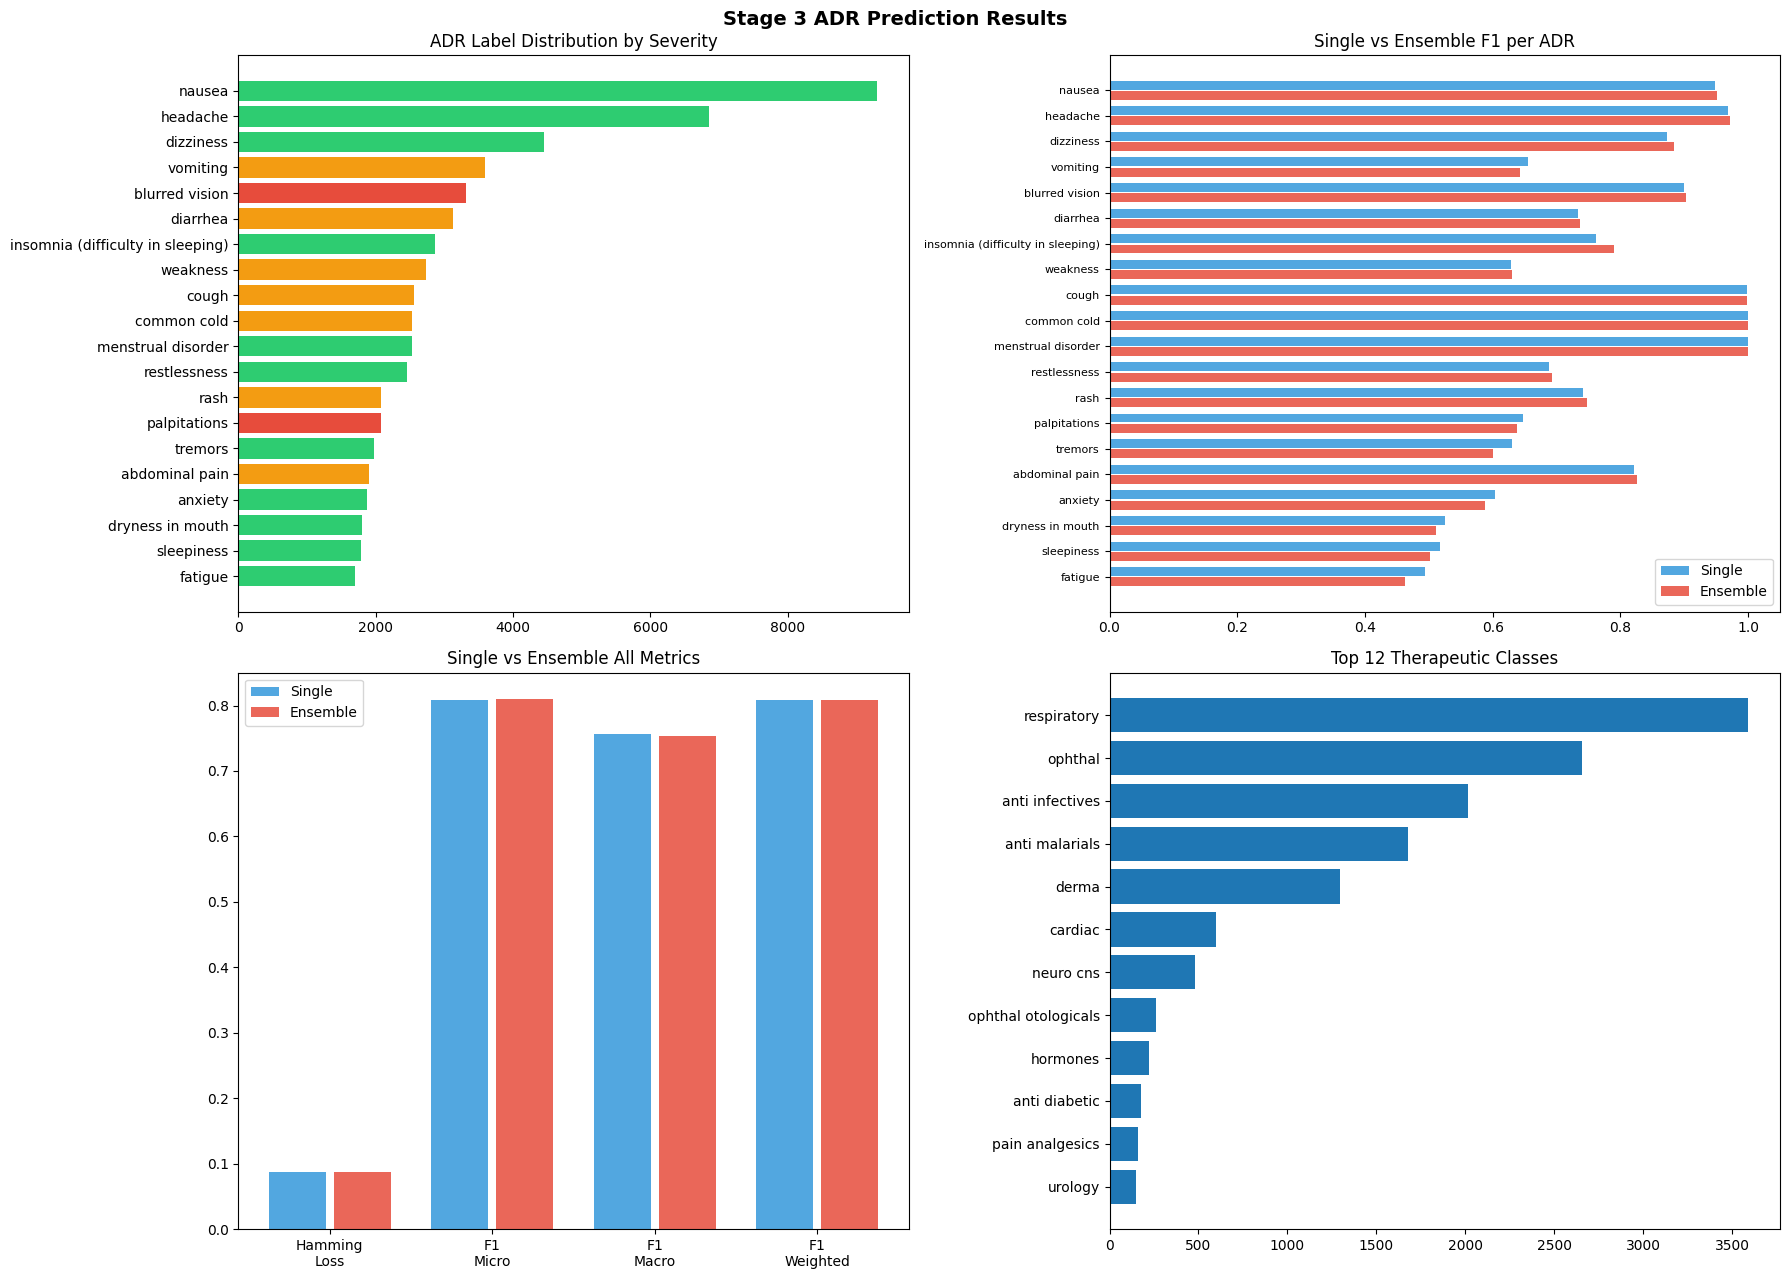

Plots saved


In [19]:
# Cell 19: Visualization
SEVERITY_LABELS = {0:'SEVERE', 1:'MODERATE', 2:'MILD'}
SEVERITY_ADVICE = {
    'SEVERE'  : 'STOP. Seek IMMEDIATE medical help.',
    'MODERATE': 'Monitor. Consult doctor promptly.',
    'MILD'    : 'Usually resolves. Inform at next visit.'
}

def sev_color(adr):
    s = ADR_SEVERITY.get(adr, 2)
    return '#e74c3c' if s==0 else '#f39c12' if s==1 else '#2ecc71'

colors  = [sev_color(a) for a in TOP_ADRS]
f1_s_per = f1_score(y_test, y_pred,      average=None, zero_division=0)
f1_e_per = f1_score(y_test, y_ensemble,  average=None, zero_division=0)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Stage 3 ADR Prediction Results', fontsize=14, fontweight='bold')

ax1 = axes[0, 0]
counts = y.sum(axis=0)
ax1.barh(TOP_ADRS, counts, color=colors)
ax1.set_title('ADR Label Distribution by Severity')
ax1.invert_yaxis()

ax2 = axes[0, 1]
pos = np.arange(len(TOP_ADRS))
ax2.barh(pos-0.2, f1_s_per, 0.35, label='Single',   color='#3498db', alpha=0.85)
ax2.barh(pos+0.2, f1_e_per, 0.35, label='Ensemble', color='#e74c3c', alpha=0.85)
ax2.set_yticks(pos)
ax2.set_yticklabels(TOP_ADRS, fontsize=8)
ax2.set_title('Single vs Ensemble F1 per ADR')
ax2.legend()
ax2.invert_yaxis()

ax3 = axes[1, 0]
metrics = ['Hamming\nLoss','F1\nMicro','F1\nMacro','F1\nWeighted']
sv = [hl_s, f1_mi_s, f1_ma_s, f1_wt_s]
ev = [hl_e, f1_mi_e, f1_ma_e, f1_wt_e]
x  = np.arange(len(metrics))
ax3.bar(x-0.2, sv, 0.35, label='Single',   color='#3498db', alpha=0.85)
ax3.bar(x+0.2, ev, 0.35, label='Ensemble', color='#e74c3c', alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(metrics)
ax3.set_title('Single vs Ensemble All Metrics')
ax3.legend()

ax4 = axes[1, 1]
tc_counts = stage3_df['therapeutic_class'].value_counts().head(12)
ax4.barh(tc_counts.index, tc_counts.values)
ax4.set_title('Top 12 Therapeutic Classes')
ax4.invert_yaxis()

plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/stage3_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved')

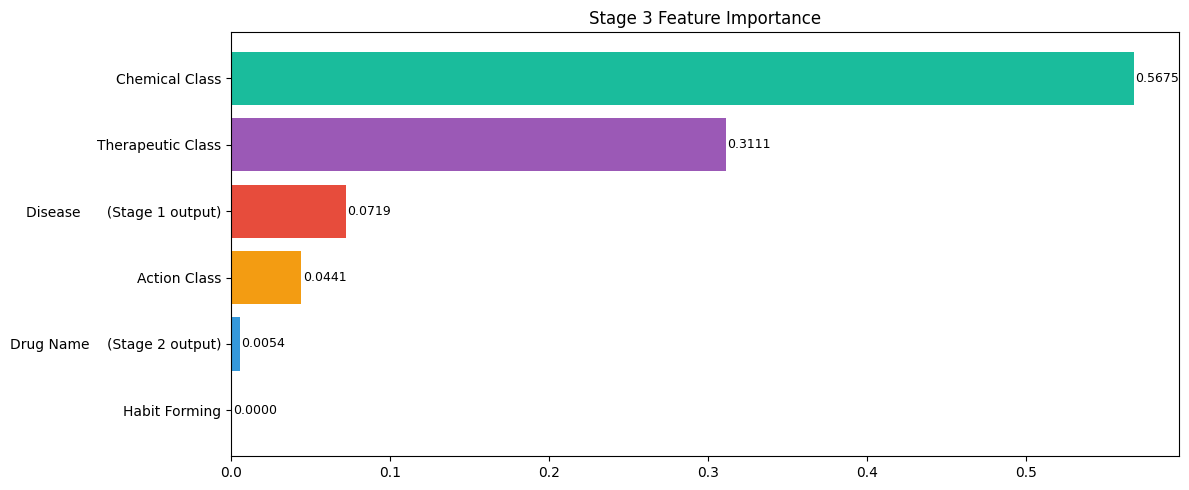

Feature importance saved


In [20]:
# Cell 20: Feature Importance
importances = chain_model.estimators_[0].feature_importances_

feat_labels = [
    'Disease      (Stage 1 output)',
    'Drug Name    (Stage 2 output)',
    'Therapeutic Class',
    'Chemical Class',
    'Habit Forming',
    'Action Class',
]

sorted_idx = np.argsort(importances)
bar_colors = ['#e74c3c','#3498db','#9b59b6','#1abc9c','#e67e22','#f39c12']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    [feat_labels[i] for i in sorted_idx],
    importances[sorted_idx],
    color=[bar_colors[i % len(bar_colors)] for i in sorted_idx]
)
ax.set_title('Stage 3 Feature Importance')
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/stage3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance saved')

In [21]:
# Cell 21: Save All Stage 3 Models
save_dir = '../models_trained'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(chain_model,     f'{save_dir}/chain_adr_model.pkl')
joblib.dump(ensemble_models, f'{save_dir}/ensemble_adr_models.pkl')
joblib.dump(mlb,             f'{save_dir}/mlb_adr.pkl')
joblib.dump(le_drug_s3,      f'{save_dir}/le_adr_drug.pkl')
joblib.dump(le_tc,           f'{save_dir}/le_adr_tc.pkl')
joblib.dump(le_cc,           f'{save_dir}/le_adr_cc.pkl')
joblib.dump(le_ac,           f'{save_dir}/le_adr_ac.pkl')
joblib.dump(TOP_ADRS,        f'{save_dir}/stage3_adr_labels.pkl')
joblib.dump(FEATURE_COLS,    f'{save_dir}/stage3_feature_cols.pkl')
joblib.dump(ADR_SEVERITY,    f'{save_dir}/adr_severity_dict.pkl')
joblib.dump(chain_order,     f'{save_dir}/chain_order.pkl')
joblib.dump(hf_map,          f'{save_dir}/hf_map.pkl')
joblib.dump(med_mapping,     f'{save_dir}/disease_mapping.pkl')

print('All Stage 3 models saved')
print('\nmodels_trained/ contents:')
for f in sorted(os.listdir(save_dir)):
    sz = os.path.getsize(f'{save_dir}/{f}') / 1024
    print(f'  {f:<45} {sz:>8.1f} KB')

All Stage 3 models saved

models_trained/ contents:
  X_test.csv                                       256.6 KB
  X_train_clean.npy                               4059.1 KB
  adr_severity_dict.pkl                              0.3 KB
  chain_adr_model.pkl                             8318.8 KB
  chain_order.pkl                                    0.1 KB
  disease_mapping.pkl                                0.5 KB
  drug_class_bridge.pkl                              4.1 KB
  drug_feature_names.pkl                             2.3 KB
  drug_scaler.pkl                                    3.7 KB
  ensemble_adr_models.pkl                       128840.6 KB
  feature_names.pkl                                  2.3 KB
  hf_map.pkl                                         0.1 KB
  label_encoder.pkl                                  1.1 KB
  le_adr_ac.pkl                                      2.0 KB
  le_adr_cc.pkl                                      1.9 KB
  le_adr_drug.pkl                               

In [22]:
# Cell 22: Full Pipeline Test
# FIX: Removed duplicate Cell 23 (was identical to this cell)

# Load all Stage 1 + 2 models
xgb_disease   = joblib.load('../models_trained/xgb_disease_model.pkl')
le_s1         = joblib.load('../models_trained/label_encoder.pkl')
severity_dict = joblib.load('../models_trained/severity_dict.pkl')
feature_names = joblib.load('../models_trained/feature_names.pkl')
rf_drug       = joblib.load('../models_trained/rf_drug_model.pkl')
le_drug_s2    = joblib.load('../models_trained/le_drug.pkl')

# Fast lookup index
feature_index = {name: i for i, name in enumerate(feature_names)}

TC_BRIDGE = {
    'antimalarial drugs':'anti malarial', 'antibiotics':'anti infectives',
    'antiviral drugs':'anti infectives',  'antihistamines':'respiratory',
    'lisinopril':'cardiac',               'sumatriptan':'neuro cns',
    'chloroquine':'anti malarial',        'ciprofloxacin':'anti infectives',
    'ursodiol':'gastro intestinal',       'dulaglutide':'anti diabetic',
    'isoniazid':'anti infectives',        'acyclovir':'anti infectives',
    'acetaminophen':'pain analgesics',    'fluconazole':'anti infectives',
    'prednisolone':'hormones',            'meclizine':'neuro cns',
    'amoxicillin':'anti infectives',      'diphenhydramine':'respiratory',
}

def full_pipeline_predict(symptom_list, verbose=True):
    # Stage 1
    vec = np.zeros(len(feature_names))
    for sym in symptom_list:
        s = sym.strip().lower().replace(' ', '_')
        if s in feature_index:
            vec[feature_index[s]] = severity_dict.get(s, 1)

    disease_code = xgb_disease.predict([vec])[0]
    disease_name = le_s1.inverse_transform([disease_code])[0]
    disease_conf = xgb_disease.predict_proba([vec]).max()

    # Stage 2
    drug_code = rf_drug.predict([vec])[0]
    drug_name = le_drug_s2.inverse_transform([drug_code])[0]
    drug_conf = rf_drug.predict_proba([vec]).max()

    # Stage 3
    try:    d_enc = le_disease_s1.transform([disease_name.strip()])[0]
    except: d_enc = 0

    drug_lower = drug_name.lower().strip()
    try:    dr_enc = le_drug_s3.transform([drug_lower])[0]
    except: dr_enc = 0

    drug_row = new_df[new_df['drug_lower'] == drug_lower]
    if len(drug_row) > 0:
        tc_val = str(drug_row.iloc[0]['therapeutic_class']).lower().strip()
        cc_val = str(drug_row.iloc[0]['chemical_class']).lower().strip()
        hf_val = str(drug_row.iloc[0]['habit_forming']).strip()
        ac_val = str(drug_row.iloc[0].get('action_class',
                     drug_row.iloc[0].get('Action Class', 'unknown'))).lower().strip()
    else:
        tc_val = TC_BRIDGE.get(drug_lower, 'unknown')
        cc_val = 'unknown'; hf_val = 'No'; ac_val = 'unknown'

    try:    tc_enc = le_tc.transform([tc_val])[0]
    except: tc_enc = 0
    try:    cc_enc = le_cc.transform([cc_val])[0]
    except: cc_enc = 0
    try:    ac_enc = le_ac.transform([ac_val])[0]
    except: ac_enc = 0
    hf_enc = hf_map.get(hf_val, 1)

    x3    = np.array([[d_enc, dr_enc, tc_enc, cc_enc, hf_enc, ac_enc]])
    proba = chain_model.predict_proba(x3)[0]

    adr_results = sorted(zip(TOP_ADRS, proba), key=lambda x: x[1], reverse=True)

    if verbose:
        print('='*65)
        print(f'  Stage 1 -> Disease : {disease_name} ({disease_conf*100:.1f}%)')
        print(f'  Stage 2 -> Drug    : {drug_name} ({drug_conf*100:.1f}%)')
        print(f'  Stage 3 -> ADRs    :')
        for adr, prob in adr_results:
            if prob > 0.05:
                sev = SEVERITY_LABELS[ADR_SEVERITY.get(adr, 2)]
                print(f'    {adr:<45} {prob:>7.1%}  [{sev}]')
        print('='*65)

    return {'disease': disease_name, 'drug': drug_name, 'adrs': adr_results}

print('TEST 1 - Malaria:')
full_pipeline_predict(['chills','vomiting','high_fever','sweating','headache','nausea','diarrhoea','muscle_pain'])

print('\nTEST 2 - Diabetes:')
full_pipeline_predict(['increased_appetite','polyuria','excessive_hunger','fatigue','weight_loss','blurred_and_distorted_vision','restlessness','irregular_sugar_level'])

print('\nTEST 3 - Hypothyroidism:')
full_pipeline_predict(['fatigue','weight_gain','cold_hands_and_feets','constipation','depression','enlarged_thyroid','brittle_nails','swollen_extremities'])

TEST 1 - Malaria:
  Stage 1 -> Disease : Malaria (99.7%)
  Stage 2 -> Drug    : chloroquine (44.6%)
  Stage 3 -> ADRs    :
    headache                                        98.5%  [MILD]
    dizziness                                       97.2%  [MILD]
    weakness                                        90.3%  [MODERATE]
    vomiting                                         7.9%  [MODERATE]

TEST 2 - Diabetes:
  Stage 1 -> Disease : Diabetes (99.6%)
  Stage 2 -> Drug    : Insulin (70.5%)
  Stage 3 -> ADRs    :

TEST 3 - Hypothyroidism:
  Stage 1 -> Disease : Hypothyroidism (99.6%)
  Stage 2 -> Drug    : ciprofloxacin (6.7%)
  Stage 3 -> ADRs    :
    headache                                        97.8%  [MILD]
    dizziness                                       89.4%  [MILD]
    weakness                                        72.6%  [MODERATE]
    vomiting                                        42.6%  [MODERATE]


{'disease': 'Hypothyroidism',
 'drug': 'ciprofloxacin',
 'adrs': [('headache', np.float64(0.9777855277061462)),
  ('dizziness', np.float64(0.8942311406135559)),
  ('weakness', np.float64(0.7258446216583252)),
  ('vomiting', np.float64(0.4260123670101166)),
  ('palpitations', np.float64(0.045287542045116425)),
  ('diarrhea', np.float64(0.005155268125236034)),
  ('nausea', np.float64(0.0017678518779575825)),
  ('dryness in mouth', np.float64(0.0007461995701305568)),
  ('tremors', np.float64(0.0005763817462138832)),
  ('blurred vision', np.float64(0.0005752108991146088)),
  ('cough', np.float64(0.0004779037262778729)),
  ('sleepiness', np.float64(0.0004523598472587764)),
  ('rash', np.float64(0.00030562066240236163)),
  ('insomnia (difficulty in sleeping)', np.float64(0.00030482711736112833)),
  ('menstrual disorder', np.float64(0.000267709867330268)),
  ('fatigue', np.float64(0.00016980632790364325)),
  ('common cold', np.float64(0.00011991993233095855)),
  ('abdominal pain', np.float64(

In [23]:
# Cell 23: More Test Cases
print('TEST - Dengue:')
full_pipeline_predict(['skin_rash','chills','joint_pain','vomiting','fatigue',
                        'high_fever','headache','nausea','loss_of_appetite',
                        'pain_behind_the_eyes','back_pain','muscle_pain','red_spots_over_body'])

print('\nTEST - Tuberculosis:')
full_pipeline_predict(['chills','vomiting','fatigue','weight_loss','cough','high_fever',
                        'breathlessness','sweating','loss_of_appetite','mild_fever',
                        'yellowing_of_eyes','swelled_lymph_nodes','malaise','phlegm',
                        'chest_pain','blood_in_sputum'])

print('\nTEST - Jaundice:')
full_pipeline_predict(['itching','vomiting','fatigue','weight_loss',
                        'high_fever','yellowish_skin','dark_urine','abdominal_pain'])

print('\nTEST - Pneumonia:')
full_pipeline_predict(['chills','fatigue','cough','high_fever','breathlessness',
                        'sweating','malaise','phlegm','chest_pain','fast_heart_rate','rusty_sputum'])

print('\nTEST - Typhoid:')
full_pipeline_predict(['chills','vomiting','fatigue','high_fever','headache',
                        'nausea','constipation','abdominal_pain','diarrhoea','belly_pain'])

TEST - Dengue:
  Stage 1 -> Disease : Dengue (99.5%)
  Stage 2 -> Drug    : acetaminophen (76.4%)
  Stage 3 -> ADRs    :
    sleepiness                                      94.5%  [MILD]
    vomiting                                        27.0%  [MODERATE]
    dryness in mouth                                 8.4%  [MILD]
    blurred vision                                   7.6%  [SEVERE]

TEST - Tuberculosis:
  Stage 1 -> Disease : Tuberculosis (99.6%)
  Stage 2 -> Drug    : isoniazid (89.3%)
  Stage 3 -> ADRs    :
    nausea                                         100.0%  [MILD]
    rash                                            99.3%  [MODERATE]
    vomiting                                        81.8%  [MODERATE]

TEST - Jaundice:
  Stage 1 -> Disease : Jaundice (99.8%)
  Stage 2 -> Drug    : ursodiol (52.7%)
  Stage 3 -> ADRs    :
    weakness                                        42.1%  [MODERATE]

TEST - Pneumonia:
  Stage 1 -> Disease : Pneumonia (99.6%)
  Stage 2 -> Drug    :

{'disease': 'Typhoid',
 'drug': 'ciprofloxacin',
 'adrs': [('nausea', np.float64(0.9996687173843384)),
  ('rash', np.float64(0.992863118648529)),
  ('vomiting', np.float64(0.8178170323371887)),
  ('diarrhea', np.float64(0.010237990878522396)),
  ('headache', np.float64(0.0038150849286466837)),
  ('weakness', np.float64(0.0017005233094096184)),
  ('insomnia (difficulty in sleeping)', np.float64(0.0016518458724021912)),
  ('cough', np.float64(0.0016250305343419313)),
  ('restlessness', np.float64(0.0007111710729077458)),
  ('abdominal pain', np.float64(0.0007020776974968612)),
  ('sleepiness', np.float64(0.000620833714492619)),
  ('blurred vision', np.float64(0.000586531707085669)),
  ('dizziness', np.float64(0.0005764603265561163)),
  ('dryness in mouth', np.float64(0.00047841350897215307)),
  ('anxiety', np.float64(0.00035469274735078216)),
  ('fatigue', np.float64(0.00028633110923692584)),
  ('menstrual disorder', np.float64(0.000267709867330268)),
  ('palpitations', np.float64(0.0002